## Problem Statement:
### You are hired by a company Gem Stones co ltd, which is a cubic zirconia manufacturer. You are provided with the dataset containing the prices and other attributes of almost 27,000 cubic zirconia (which is an inexpensive diamond alternative with many of the same qualities as a diamond). The company is earning different profits on different prize slots. You have to help the company in predicting the price for the stone on the basis of the details given in the dataset so it can distinguish between higher profitable stones and lower profitable stones so as to have a better profit share. Also, provide them with the best 5 attributes that are most important.

## Task you can perform 📝
1. 📌 Clean and preprocess the data.
2. 📌 Do Exploratory Data Analysis (EDA) to get some insight into data.
3. 📌 Do Feature Engineering.
4. 📌 Build a model i.e Regression Analysis.
5. 📌 Evaluate the model.
6. 📌 Go back to any of the previous steps unless the result is sufficient.

In [ ]:
# Data ingestion

In [2]:
import pandas as pd
import numpy as np

In [3]:

df_original = pd.read_csv("E://Python Projects//ML//Diamond Price Prediction//notebooks//data//cubic_zirconia.csv")

In [4]:
df_original

,Unnamed: 0,carat,cut,color,clarity,depth,table,x,y,z,price
0,1,0.30,Ideal,E,SI1,62.1,58.0,4.27,4.29,2.66,499
1,2,0.33,Premium,G,IF,60.8,58.0,4.42,4.46,2.70,984
2,3,0.90,Very Good,E,VVS2,62.2,60.0,6.04,6.12,3.78,6289
3,4,0.42,Ideal,F,VS1,61.6,56.0,4.82,4.80,2.96,1082
4,5,0.31,Ideal,F,VVS1,60.4,59.0,4.35,4.43,2.65,779
...,...,...,...,...,...,...,...,...,...,...,...
26962,26963,1.11,Premium,G,SI1,62.3,58.0,6.61,6.52,4.09,5408
26963,26964,0.33,Ideal,H,IF,61.9,55.0,4.44,4.42,2.74,1114
26964,26965,0.51,Premium,E,VS2,61.7,58.0,5.12,5.15,3.17,1656
26965,26966,0.27,Very Good,F,VVS2,61.8,56.0,4.19,4.20,2.60,682


In [5]:
df_original.shape

(26967, 11)

In [6]:
df_original.size

296637

In [7]:
df_original.describe()

,Unnamed: 0,carat,depth,table,x,y,z,price
count,26967.000000,26967.000000,26270.000000,26967.000000,26967.000000,26967.000000,26967.000000,26967.000000
mean,13484.000000,0.798375,61.745147,57.456080,5.729854,5.733569,3.538057,3939.518115
std,7784.846691,0.477745,1.412860,2.232068,1.128516,1.166058,0.720624,4024.864666
min,1.000000,0.200000,50.800000,49.000000,0.000000,0.000000,0.000000,326.000000
25%,6742.500000,0.400000,61.000000,56.000000,4.710000,4.710000,2.900000,945.000000
50%,13484.000000,0.700000,61.800000,57.000000,5.690000,5.710000,3.520000,2375.000000
75%,20225.500000,1.050000,62.500000,59.000000,6.550000,6.540000,4.040000,5360.000000
max,26967.000000,4.500000,73.600000,79.000000,10.230000,58.900000,31.800000,18818.000000


In [22]:
df_original.isnull().sum()

Unnamed: 0      0
carat           0
cut             0
color           0
clarity         0
depth         697
table           0
x               0
y               0
z               0
price           0
dtype: int64

Only values from deepth are missing

In [25]:
df_original.duplicated().sum()

np.int64(0)

In [8]:

num_data = df_original.select_dtypes(include='number')

In [12]:
cat_data = df_original.select_dtypes(include=['object','category'])

In [13]:
num_data.corr()

,Unnamed: 0,carat,depth,table,x,y,z,price
Unnamed: 0,1.000000,0.003490,-0.001588,0.003817,0.004626,0.006844,0.001681,0.002650
carat,0.003490,1.000000,0.035364,0.181685,0.976368,0.941071,0.940640,0.922416
depth,-0.001588,0.035364,1.000000,-0.298011,-0.018715,-0.024735,0.101624,-0.002569
table,0.003817,0.181685,-0.298011,1.000000,0.196206,0.182346,0.148944,0.126942
x,0.004626,0.976368,-0.018715,0.196206,1.000000,0.962715,0.956606,0.886247
y,0.006844,0.941071,-0.024735,0.182346,0.962715,1.000000,0.928923,0.856243
z,0.001681,0.940640,0.101624,0.148944,0.956606,0.928923,1.000000,0.850536
price,0.002650,0.922416,-0.002569,0.126942,0.886247,0.856243,0.850536,1.000000


In [14]:
num_data

,Unnamed: 0,carat,depth,table,x,y,z,price
0,1,0.30,62.1,58.0,4.27,4.29,2.66,499
1,2,0.33,60.8,58.0,4.42,4.46,2.70,984
2,3,0.90,62.2,60.0,6.04,6.12,3.78,6289
3,4,0.42,61.6,56.0,4.82,4.80,2.96,1082
4,5,0.31,60.4,59.0,4.35,4.43,2.65,779
...,...,...,...,...,...,...,...,...
26962,26963,1.11,62.3,58.0,6.61,6.52,4.09,5408
26963,26964,0.33,61.9,55.0,4.44,4.42,2.74,1114
26964,26965,0.51,61.7,58.0,5.12,5.15,3.17,1656
26965,26966,0.27,61.8,56.0,4.19,4.20,2.60,682


In [16]:
cat_data

,cut,color,clarity
0,Ideal,E,SI1
1,Premium,G,IF
2,Very Good,E,VVS2
3,Ideal,F,VS1
4,Ideal,F,VVS1
...,...,...,...
26962,Premium,G,SI1
26963,Ideal,H,IF
26964,Premium,E,VS2
26965,Very Good,F,VVS2


# EDA anaiysis

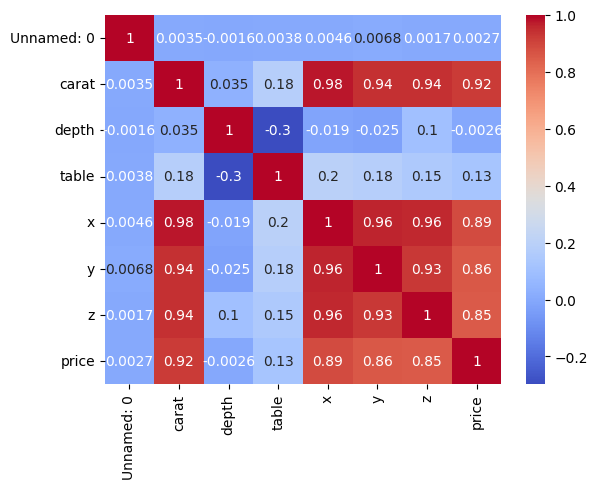

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = num_data.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

<Axes: xlabel='carat', ylabel='Count'>

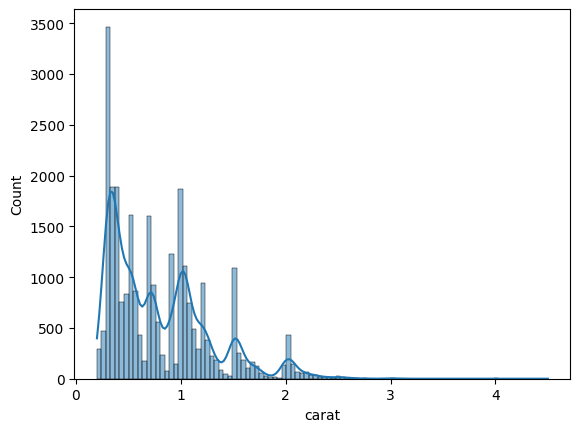

<Axes: xlabel='carat'>

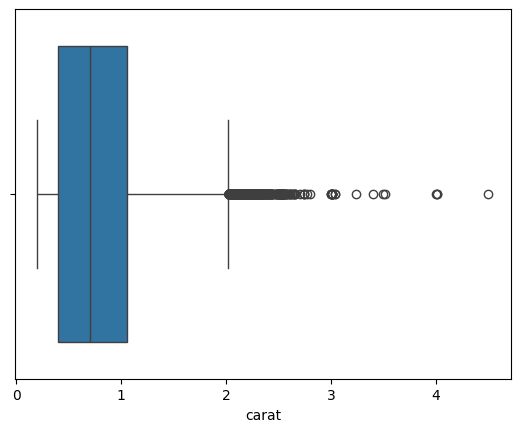

In [29]:
sns.boxplot(x=df_original['carat'])

<function matplotlib.pyplot.show(close=None, block=None)>

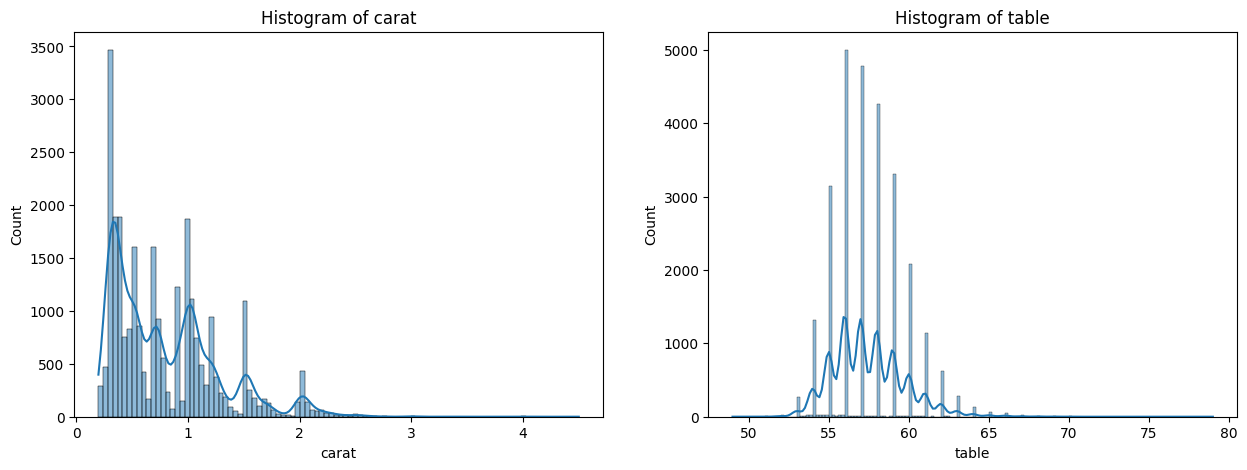

In [43]:
f,ax = plt.subplots(1,2,figsize=[15,5])

# Title of grapha
ax[0].set_title("Histogram of carat")
ax[1].set_title("Histogram of table")

sns.histplot(data=num_data,x=num_data['carat'],kde=True,ax=ax[0])
sns.histplot(data=num_data,x=num_data['table'],kde=True,ax=ax[1])

plt.tight_layout
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

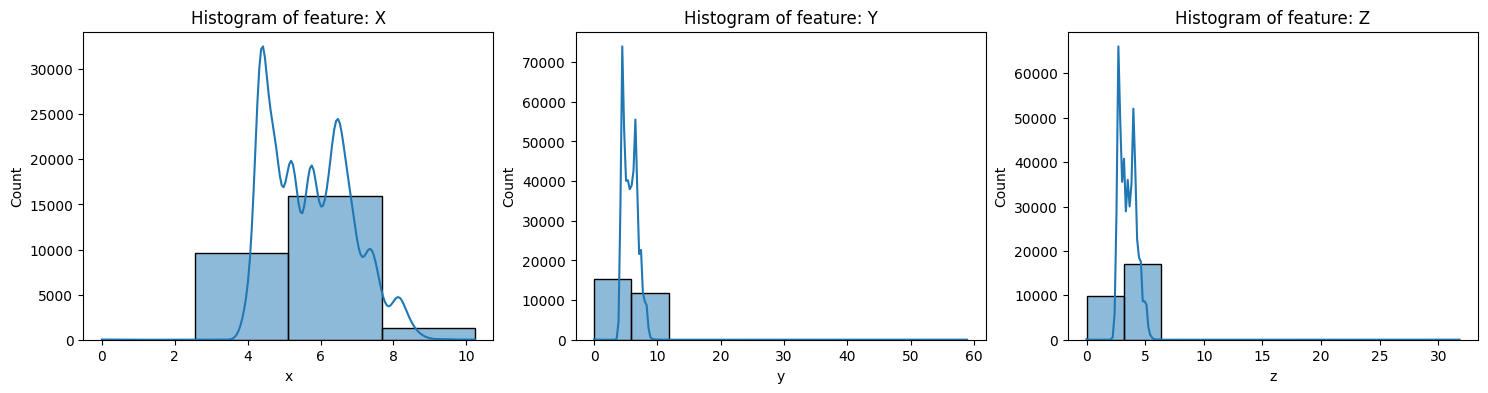

In [60]:
f,ax = plt.subplots(1,3,figsize=[18,4])

ax[0].set_title("Histogram of feature: X")
ax[1].set_title("Histogram of feature: Y")
ax[2].set_title("Histogram of feature: Z")

sns.histplot(data=df_original,x=df_original['x'],kde=True,ax=ax[0],bins=4)
sns.histplot(data=df_original,x=df_original['y'],kde=True,ax=ax[1],bins=10)
sns.histplot(data=df_original,x=df_original['z'],kde=True,ax=ax[2],bins=10)

plt.tight_layout
plt.show

In [ ]:
f,ax = plt.subplots(1,3,figsize=[18,4])

ax[0].set_title("Histogram of feature: X")
ax[1].set_title("Histogram of feature: Y")
ax[2].set_title("Histogram of feature: Z")

sns.histplot(data=df_original,x=df_original['x'],kde=True,ax=ax[0],bins=4)
sns.histplot(data=df_original,x=df_original['y'],kde=True,ax=ax[1],bins=10)
sns.histplot(data=df_original,x=df_original['z'],kde=True,ax=ax[2],bins=10)

plt.tight_layout
plt.show

<Axes: xlabel='carat', ylabel='price'>

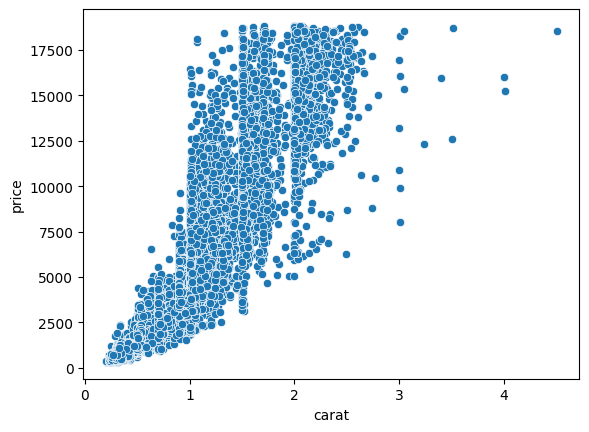

In [61]:
sns.scatterplot(x=df_original['carat'], y=df_original['price'])